In [22]:
# Step 1: Get virial velocities for different snapshots
# Based on code from a3_mstar_new.py (lines 48-66)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import illustris_python as il
import sys
import os


font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size' : 14}
import matplotlib
plt.figure()
plt.close()
matplotlib.rc('font', **font)
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelweight'] = 'bold'
FIGURE_SAVE_PATH = '/bigdata/saleslab/psadh003/project3_aegis/figures_paper/'

# Add grid with which='both' and ls=':' by default to all plots
# plt.rcParams['axes.grid'] = True
# plt.rcParams['axes.grid.which'] = 'both'
# plt.rcParams['grid.linestyle'] = ':'
# plt.rcParams['axes.grid.axis'] = 'both'
# plt.rcParams['axes.grid.zorder'] = 0  # Ensure grid is always in the background


label_font = 14

# Add path for constants
sys.path.append(os.path.abspath('/bigdata/saleslab/psadh003/tng50/dwarf_formation'))
sys.path.append(os.path.abspath('/bigdata/saleslab/psadh003/tng50-dark-analysis'))
from constants import *  # This provides basePath, h, G, etc.

filepath = '/rhome/psadh003/bigdata/tng50/tng_files/'
basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'

# Set up parameters
# You can change fofno here or make it an input
fofno = 0  # FoF halo number - change this as needed
fofstr = 'fof' + str(int(fofno))

# Load ages and redshifts
ages_df = pd.read_csv(filepath + 'ages_tng.csv', comment='#')
all_snaps = np.array(ages_df['snapshot'])
all_redshifts = np.array(ages_df['redshift'])
all_ages = np.array(ages_df['age(Gyr)'])

# Get central subhalo at snapshot 99
this_fof = il.groupcat.loadSingle(basePath, 99, haloID=fofno)
central_sfid_99 = this_fof['GroupFirstSub']

# Load central tree to get properties at all snapshots
central_fields = ['GroupFirstSub', 'SubhaloGrNr', 'SnapNum', 'GroupNsubs', 
                   'SubhaloPos', 'Group_R_Crit200', 'Group_M_Crit200', 
                   'SubhaloVel', 'SubfindID', 'GroupMass', 'SubhaloMassInHalfRad', 'SubhaloMassInRad', 'SubhaloHalfmassRadType']
central_tree = il.sublink.loadTree(basePath, 99, central_sfid_99, 
                                    fields=central_fields, onlyMPB=True)

central_snaps = central_tree['SnapNum']
central_sfids = central_tree['SubfindID']
central_redshift = all_redshifts[central_snaps]
central_r200 = central_tree['Group_R_Crit200'] / (1 + central_redshift) / h  # kpc
central_rhalf = central_tree['SubhaloHalfmassRadType'][:, 4] / (1 + central_redshift) / h  # kpc, 4th column is half mass radius of stars
central_mhalf = central_tree['SubhaloMassInHalfRad'] * 1e10 / h  # Msun
central_massrad = central_tree['SubhaloMassInRad'] * 1e10 / h  # Msun
central_gr_m200 = central_tree['Group_M_Crit200'] * 1e10 / h  # Msun
central_mtot = central_tree['GroupMass'] * 1e10 / h  # Msun (total mass of FoF halo)

# Calculate V0 for all snapshots (in km/s)
# Using G = 4.3e-6 in units of kpc, Msun, seconds
G_iso = 4.3e-6  # kpc, Msun, seconds
central_v0 = np.sqrt(G_iso * central_gr_m200 / central_r200)  # km/s

print(f"Loaded V0 for {len(central_v0)} snapshots")
print(f"V0 range: {np.min(central_v0):.2f} - {np.max(central_v0):.2f} km/s")
print(f"Available snapshots: {np.min(central_snaps)} to {np.max(central_snaps)}")


Loaded V0 for 100 snapshots
V0 range: 16.00 - 887.47 km/s
Available snapshots: 0 to 99


In [7]:
import numpy as np
from scipy.integrate import quad

# Define the density profile ρ(r) for isothermal sphere
def rho_isothermal(r, V0=200, G=4.3e-6):  # V0 in km/s
    # r in kpc, V0 in km/s, G in kpc, Msun, seconds
    return V0**2 / (4 * np.pi * G * r**2)

# Integrate 4πr^2 * ρ(r) over r = [r_min, r_max]
# The mass enclosed between r_min and r_max
def mass_isothermal(V0=200, G=4.3e-6, r_min=1e-6, r_max=100000):
    # r_min small to avoid singularity at r=0
    integrand = lambda r: 4 * np.pi * r**2 * rho_isothermal(r, V0=V0, G=G)
    mass, err = quad(integrand, r_min, r_max, limit=1000)
    return mass

# Use a sample V0; for demonstration, take V0 of snapshot 99
V0_snap = central_v0[central_snaps == 99][0] if np.any(central_snaps == 99) else central_v0[-1]
M_enc = mass_isothermal(V0=V0_snap, r_max = 1e10)

print(f"Enclosed mass (0-100000 kpc) for V0 = {V0_snap:.2f} km/s: {M_enc:.3e} Msun")


Enclosed mass (0-100000 kpc) for V0 = 811.48 km/s: 1.531e+21 Msun


In [ ]:
# Step 2: Define GALPY PowerSphericalPotential
# Reference: https://docs.galpy.org/en/stable/reference/potentialpowerspher.html

from galpy.potential import PowerSphericalPotentialwCutoff
from astropy import units as u

# Function to get potential for a given snapshot
def get_potential_for_snapshot(snapshot):
    """
    Get PowerSphericalPotentialwCutoff for a given snapshot.
    
    Parameters:
    -----------
    snapshot : int
        Snapshot number
        
    Returns:
    --------
    pot : PowerSphericalPotentialwCutoff
        The potential object
    v0 : float
        The V0 value used (in km/s)
    """
    # Find index for this snapshot
    snap_idx = np.where(central_snaps == snapshot)[0]
    if len(snap_idx) == 0:
        raise ValueError(f"Snapshot {snapshot} not found in central tree")
    
    # Get V0 for this snapshot (in km/s)
    v0 = central_v0[snap_idx[0]]
    mtot = central_mtot[snap_idx[0]]
    rvir = central_r200[snap_idx[0]]
    
    # For alpha=2, the density is ρ(r) = amp/r^2
    # For an isothermal sphere: ρ(r) = V0^2/(4πG r^2)
    # So: amp = V0^2/(4πG)
    # Note: G = 4.3e-6 in units of kpc, Msun, seconds
    # GALPY uses kpc for distances and km/s for velocities
    # We need to convert G to appropriate units for GALPY
    
    # G in GALPY units: kpc^3 / (Msun * (km/s)^2)
    # 1 km/s = 1e5 cm/s = 1e5 * (1e-3 km) / s = 1e2 km/s (wait, that's wrong)
    # Actually: 1 km/s = 1 km/s
    # G = 4.3e-6 kpc^3 / (Msun * s^2)
    # We need: G in kpc^3 / (Msun * (km/s)^2)
    # 1 km/s = 1 km/s, so we need: G_galpy = G * (1 km/s)^2 / s^2
    # 1 km/s = 1e5 cm/s, and 1 s = 1 s
    # Actually, let's work in physical units
    
    # For GALPY, when using physical units:
    # G = 4.302e-3 kpc (km/s)^2 / Msun (this is the standard value)
    # But we're using G = 4.3e-6 in kpc, Msun, seconds
    # Conversion: 1 km/s = 1e5 cm/s, and we need to convert properly
    
    # Actually, let's use the standard GALPY approach:
    # For PowerSphericalPotentialwCutoff with alpha=2:
    # ρ(r) = amp/(r1^3) * (r1/r)^2 = amp/(r1 * r^2)
    # For isothermal: ρ(r) = V0^2/(4πG r^2)
    # So: amp/(r1 * r^2) = V0^2/(4πG r^2)
    # Therefore: amp = V0^2 * r1 / (4πG)
    
    # G in kpc^3 / (Msun * (km/s)^2) = 4.302e-3
    G_galpy = 4.302e-6  # kpc (km/s)^2 / Msun (standard GALPY value)
    
    # Set reference radius
    r1 = 1.0  # kpc
    
    # Calculate amplitude: amp = (V0^2 * r1) / (4πG)
    # Units: (km/s)^2 * kpc / (kpc (km/s)^2 / Msun) = Msun
    amp = (v0**2) / (4 * np.pi * G_galpy * r1**2)  # in Msun/kpc^3
    rc = mtot / (2 * np.pi * np.sqrt(np.pi) * amp * r1**2)  # in kpc
    
    # Set distance and velocity scales for GALPY
    # ro = 1 kpc (distance scale), vo = 1 km/s (velocity scale)
    # This ensures all calculations are in physical units
    ro = 1.0 * u.kpc  # distance scale
    vo = 1.0 * u.km / u.s  # velocity scale
    
    # Create potential with alpha=2 (isothermal), r1=1 kpc
    # Include units: amp in Msun, r1 in kpc
    # Explicitly set ro and vo to ensure proper unit handling
    pot = PowerSphericalPotentialwCutoff(amp=amp * u.Msun / u.kpc**3, alpha=2.0, r1=r1 * u.kpc, 
                                   ro=ro, vo=vo, rc = rc * u.kpc)
    # pot.normvcircalize(mtot * u.Msun)
    
    return pot, v0

# Example: Get potential for a specific snapshot
# You can change this snapshot number
snapshot = 99  # Change this to test different snapshots
potential, v0_snapshot = get_potential_for_snapshot(snapshot)

print(f"Potential created for snapshot {snapshot}")
print(f"V0 = {v0_snapshot:.2f} km/s")
print(f"Amplitude = {potential._amp:.2e} Msun")


Potential created for snapshot 99
V0 = 811.48 km/s
Amplitude = 5.24e+04 Msun


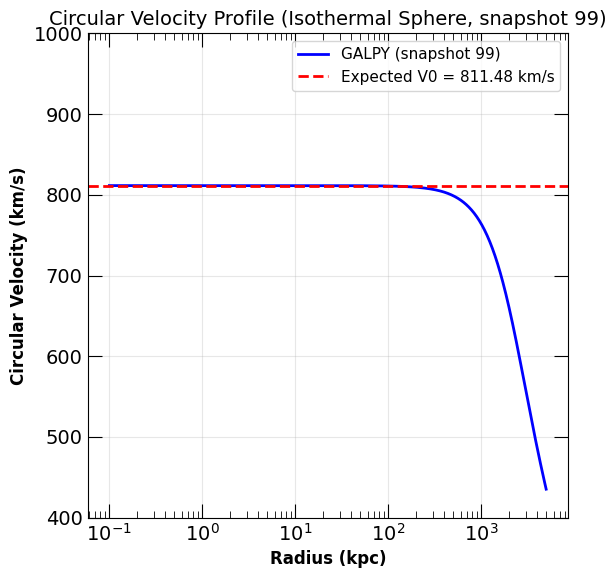


Verification:
At r = 1 kpc: v_circ = 811.38 km/s
At r = 10 kpc: v_circ = 811.38 km/s
At r = 100 kpc: v_circ = 810.87 km/s
Expected constant V0 = 811.48 km/s


In [17]:
# Step 3(i): Plot circular velocity vs radius
# Reference: https://docs.galpy.org/en/v1.9.1/reference/potentialvcirc.html

# Set snapshot to use
snapshot = 99  # Change this to test different snapshots
potential, v0_snapshot = get_potential_for_snapshot(snapshot)

# Create radius array (in kpc)
r_min = 0.1  # kpc
r_max = 5000.0  # kpc
r_array = np.logspace(np.log10(r_min), np.log10(r_max), 1000)  # kpc

# Calculate circular velocity at each radius
# vcirc expects R (cylindrical radius), but for spherical potential, R = r
vcirc_array = potential.vcirc(r_array * u.kpc)
# print(f"Units of circular velocity output: {getattr(vcirc_array, 'unit', 'no unit attribute (likely plain ndarray)')}")

# Create plot
plt.figure()
plt.semilogx(r_array, vcirc_array, 'b-', linewidth=2, label=f'GALPY (snapshot {snapshot})')
plt.axhline(y=v0_snapshot, color='r', linestyle='--', linewidth=2, 
            label=f'Expected V0 = {v0_snapshot:.2f} km/s')
plt.xlabel('Radius (kpc)', fontsize=12)
plt.ylabel('Circular Velocity (km/s)', fontsize=12)
plt.ylim(400, 1000)
plt.title(f'Circular Velocity Profile (Isothermal Sphere, snapshot {snapshot})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some values for verification
print(f"\nVerification:")
print(f"At r = 1 kpc: v_circ = {potential.vcirc(1.0 * u.kpc):.2f} km/s")
print(f"At r = 10 kpc: v_circ = {potential.vcirc(10.0 * u.kpc):.2f} km/s")
print(f"At r = 100 kpc: v_circ = {potential.vcirc(100.0 * u.kpc):.2f} km/s")
print(f"Expected constant V0 = {v0_snapshot:.2f} km/s")


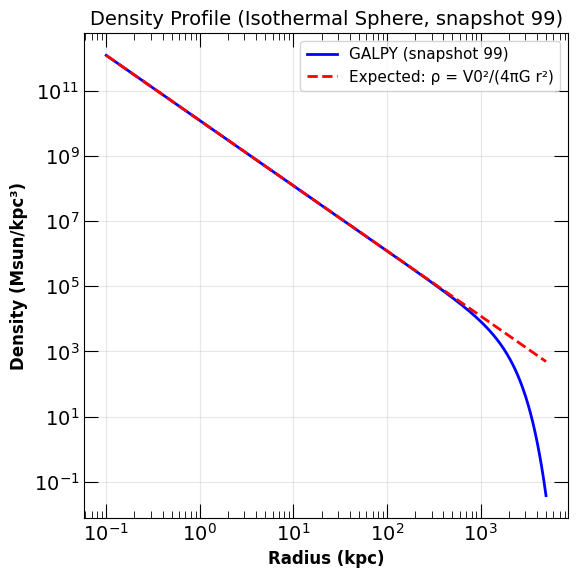


Verification:
At r = 1 kpc: ρ = 1.22e+01 Msun/kpc³
Expected at r = 1 kpc: ρ = 1.22e+12 Msun/kpc³
At r = 10 kpc: ρ = 1.22e-01 Msun/kpc³
Expected at r = 10 kpc: ρ = 1.22e+08 Msun/kpc³


In [16]:
# Step 3(ii): Plot density profile vs radius
# Reference: https://docs.galpy.org/en/v1.9.1/reference/potentialdens.html

# Use same snapshot and potential
snapshot = 99  # Change this to test different snapshots
potential, v0_snapshot = get_potential_for_snapshot(snapshot)

# Create radius array (in kpc)
r_min = 0.1  # kpc
r_max = 5000.0  # kpc
r_array = np.logspace(np.log10(r_min), np.log10(r_max), 1000)  # kpc

# Calculate density at each radius
# dens expects (R, z) where R is cylindrical radius and z is vertical height
# For spherical potential, we use R = r (3D radius) and z = 0
z_array = np.zeros_like(r_array)  # z = 0
density_array = potential.dens(r_array * u.kpc, z_array * u.kpc)  # Returns in Msun/kpc^3

# Expected density for isothermal sphere: ρ(r) = V0^2/(4πG r^2)
G_galpy = 4.302e-6  # kpc (km/s)^2 / Msun
expected_density = (v0_snapshot**2) / (4 * np.pi * G_galpy * r_array**2)

# Create plot
plt.figure()
plt.loglog(r_array, 1e9 * density_array, 'b-', linewidth=2, label=f'GALPY (snapshot {snapshot})')
plt.loglog(r_array, expected_density, 'r--', linewidth=2, 
           label=f'Expected: ρ = V0²/(4πG r²)')
plt.xlabel('Radius (kpc)', fontsize=12)
plt.ylabel('Density (Msun/kpc³)', fontsize=12)
plt.title(f'Density Profile (Isothermal Sphere, snapshot {snapshot})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some values for verification
print(f"\nVerification:")
print(f"At r = 1 kpc: ρ = {potential.dens(1.0 * u.kpc, 0.0 * u.kpc):.2e} Msun/kpc³")
print(f"Expected at r = 1 kpc: ρ = {expected_density[0]:.2e} Msun/kpc³")
print(f"At r = 10 kpc: ρ = {potential.dens(10.0 * u.kpc, 0.0 * u.kpc):.2e} Msun/kpc³")
print(f"Expected at r = 10 kpc: ρ = {expected_density[np.argmin(np.abs(r_array - 10))]:.2e} Msun/kpc³")


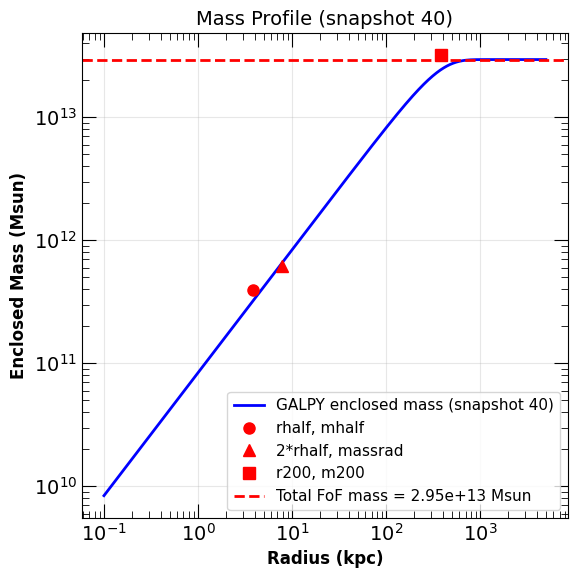


Verification:
At r = 1 kpc: M(<r) = 8.39e+10 Msun
At r = 10 kpc: M(<r) = 8.39e+11 Msun
At r = 100 kpc: M(<r) = 8.22e+12 Msun
At r = 1000 kpc: M(<r) = 2.95e+13 Msun
Total FoF mass = 2.95e+13 Msun


In [27]:
# This cell is for the mass
# Reference: https://docs.galpy.org/en/v1.9.1/reference/potentialmasses.html

from galpy.potential import mass

# Set snapshot to use
snapshot = 40  # Change this to test different snapshots
potential, v0_snapshot = get_potential_for_snapshot(snapshot)

# Get total mass for this snapshot (in Msun)
mtot_snapshot = central_mtot[central_snaps == snapshot][0]

# Create radius array (in kpc)
r_min = 0.1  # kpc
r_max = 5000.0  # kpc
r_array = np.logspace(np.log10(r_min), np.log10(r_max), 1000)  # kpc

# Calculate enclosed mass at each radius using potential.mass()
# mass(R, z=None) calculates mass enclosed within a spherical shell with radius R
# For spherical potential, we use R = r (cylindrical radius equals 3D radius)
mass_array = mass(potential, r_array * u.kpc)  # Returns in Msun

# Create plot
plt.figure()
plt.loglog(r_array, mass_array, 'b-', linewidth=2, label=f'GALPY enclosed mass (snapshot {snapshot})')
# Plot markers for characteristic radii and masses at this snapshot
# Find the index in central_snaps corresponding to this snapshot
idx = np.where(central_snaps == snapshot)[0][0]
# Get characteristic radii and masses at this snapshot
rhalf = central_rhalf[idx]
mhalf = central_mhalf[idx]
r200 = central_r200[idx]
m200 = central_gr_m200[idx]
massrad = central_massrad[idx]
# Plot (rhalf, mhalf)
plt.plot(rhalf, mhalf, 'ro', markersize=8, label='rhalf, mhalf')
# Plot (2*rhalf, massrad)
plt.plot(2*rhalf, massrad, 'r^', markersize=8, label='2*rhalf, massrad')
# Plot (r200, m200)
plt.plot(r200, m200, 'rs', markersize=8, label='r200, m200')

plt.axhline(y=mtot_snapshot, color='r', linestyle='--', linewidth=2, 
            label=f'Total FoF mass = {mtot_snapshot:.2e} Msun')
plt.xlabel('Radius (kpc)', fontsize=12)
plt.ylabel('Enclosed Mass (Msun)', fontsize=12)
plt.title(f'Mass Profile (snapshot {snapshot})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some values for verification
print(f"\nVerification:")
print(f"At r = 1 kpc: M(<r) = {mass(potential, 1.0 * u.kpc):.2e} Msun")
print(f"At r = 10 kpc: M(<r) = {mass(potential, 10.0 * u.kpc):.2e} Msun")
print(f"At r = 100 kpc: M(<r) = {mass(potential, 100.0 * u.kpc):.2e} Msun")
print(f"At r = 1000 kpc: M(<r) = {mass(potential, 1000.0 * u.kpc):.2e} Msun")
print(f"Total FoF mass = {mtot_snapshot:.2e} Msun")
